In [2]:
from pathlib import Path
import sys
import os
import pandas as pd

In [3]:
Project_DIR = Path.cwd().resolve()
if Project_DIR.name == "notebook":
    Project_DIR = Project_DIR.parent

Data_DIR = Project_DIR / "DATA"
df = pd.read_csv(Data_DIR / "dataset.csv", encoding="latin-1")
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [4]:
df.shape

(20348, 2)

In [5]:
df.describe()

,text_type,text
count,20348,20348
unique,2,20334
top,ham,SPAM ALERT ð User: Username: @DillyBu...
freq,14337,8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20348 entries, 0 to 20347
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text_type  20348 non-null  object
 1   text       20348 non-null  object
dtypes: object(2)
memory usage: 318.1+ KB


In [7]:
df.isna().sum()

text_type    0
text         0
dtype: int64

**EDA**

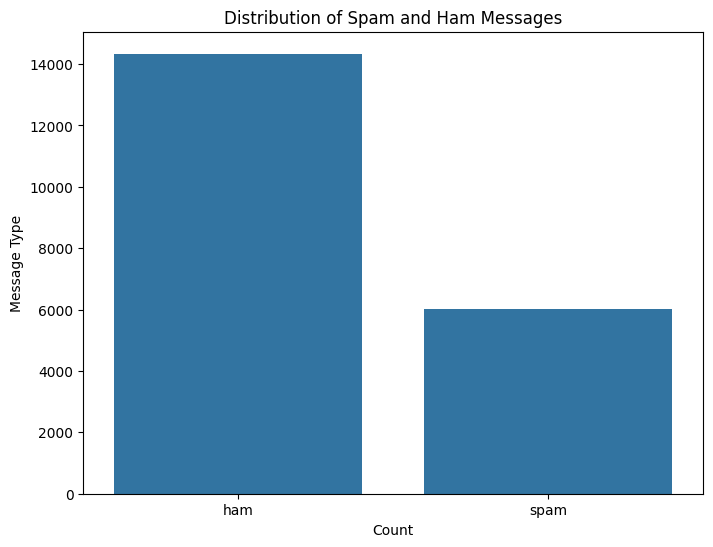

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x="text_type", data=df, order=df["text_type"].value_counts().index)
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Count")
plt.ylabel("Message Type")
plt.show()

**Text length / word count**

text_type                  ham         spam
char_len   count  14337.000000  6011.000000
           mean     314.550185   356.174347
           std      307.486082   297.800572
           min        1.000000     3.000000
           25%       42.000000   139.000000
           50%      141.000000   226.000000
           75%      686.000000   560.000000
           max     1545.000000  2584.000000
word_count count  14337.000000  6011.000000
           mean      58.212806    54.257362
           std       55.916965    42.215726
           min        1.000000     1.000000
           25%        9.000000    23.000000
           50%       27.000000    36.000000
           75%      124.000000    80.000000
           max      178.000000   211.000000


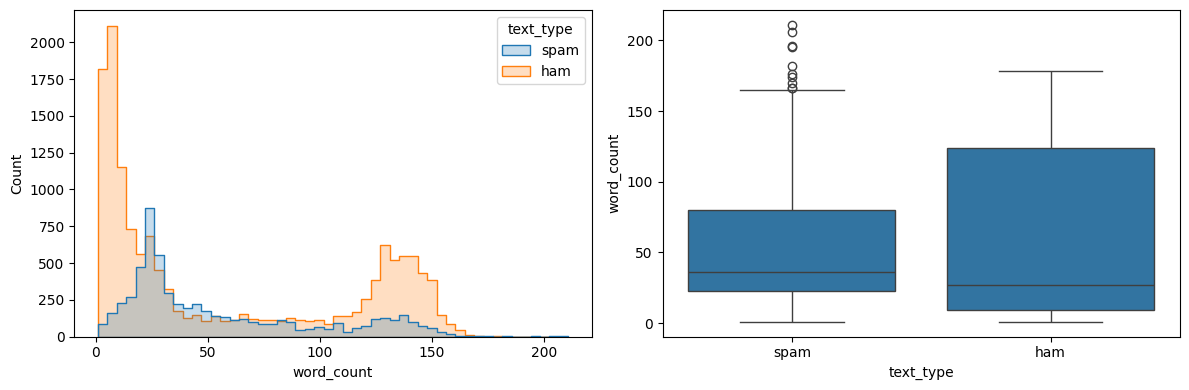

In [9]:
df["text"] = df["text"].astype(str)
df["char_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().apply(len)

print(df.groupby("text_type")[["char_len", "word_count"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x="word_count", hue="text_type", bins=50, ax=axes[0], element="step")
sns.boxplot(data=df, x="text_type", y="word_count", ax=axes[1])
plt.tight_layout()
plt.show()

**Duplicate check (label conflicts?)**

In [10]:
dupe_texts = df[df.duplicated(subset=["text"], keep=False)]
conflict_check = dupe_texts.groupby("text")["text_type"].nunique()
print("Duplicate texts:", dupe_texts["text"].nunique())
print("With conflicting labels:", (conflict_check > 1).sum())

Duplicate texts: 3
With conflicting labels: 0


**Very short texts**

In [11]:
short_texts = df[df["word_count"] < 3]
print(f"Under 3 words: {len(short_texts)} ({len(short_texts)/len(df):.1%})")
print(short_texts["text_type"].value_counts())

Under 3 words: 466 (2.3%)
text_type
ham     451
spam     15
Name: count, dtype: int64


In [13]:
Common_words = df["text"].str.lower().str.split(expand=True).stack().value_counts()
common_words 

the         33676
to          31156
i           19648
and         18662
a           17734
            ...  
binary        101
shipping      101
ca            101
rules         101
rac           101
Name: count, Length: 1332, dtype: int64

C:\Users\MSI\AppData\Local\Temp\ipykernel_29984\1858862066.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="text_type", order=df["text_type"].value_counts().index, palette="Set2")


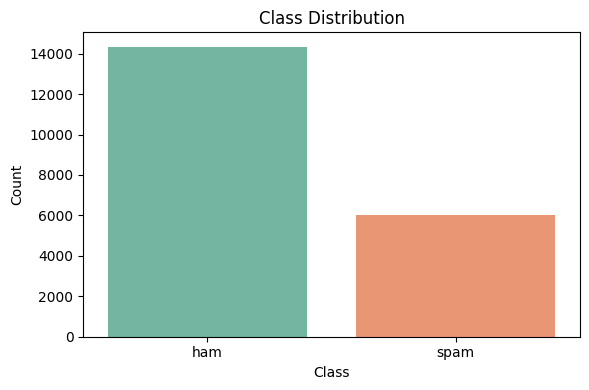

C:\Users\MSI\AppData\Local\Temp\ipykernel_29984\1858862066.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_len, x="text_type", y="word_count", palette="Set2")


text_type
ham     14337
spam     6011
Name: count, dtype: int64

Imbalance ratio: 2.39


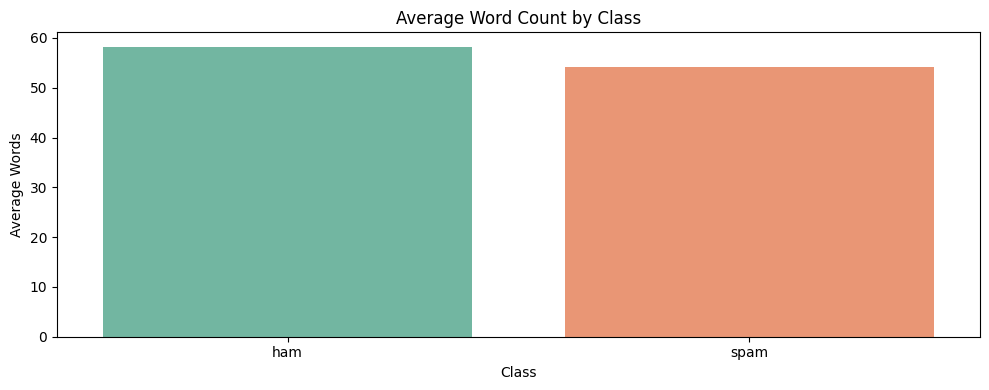

C:\Users\MSI\AppData\Local\Temp\ipykernel_29984\1858862066.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_len, x="text_type", y="char_len", palette="Set2")


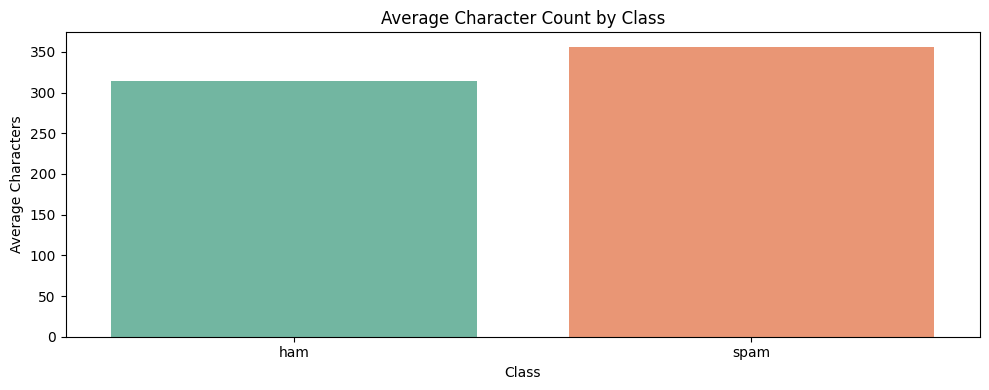

C:\Users\MSI\AppData\Local\Temp\ipykernel_29984\1858862066.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=punct_df.head(15), x="punctuation", y="count", palette="viridis")


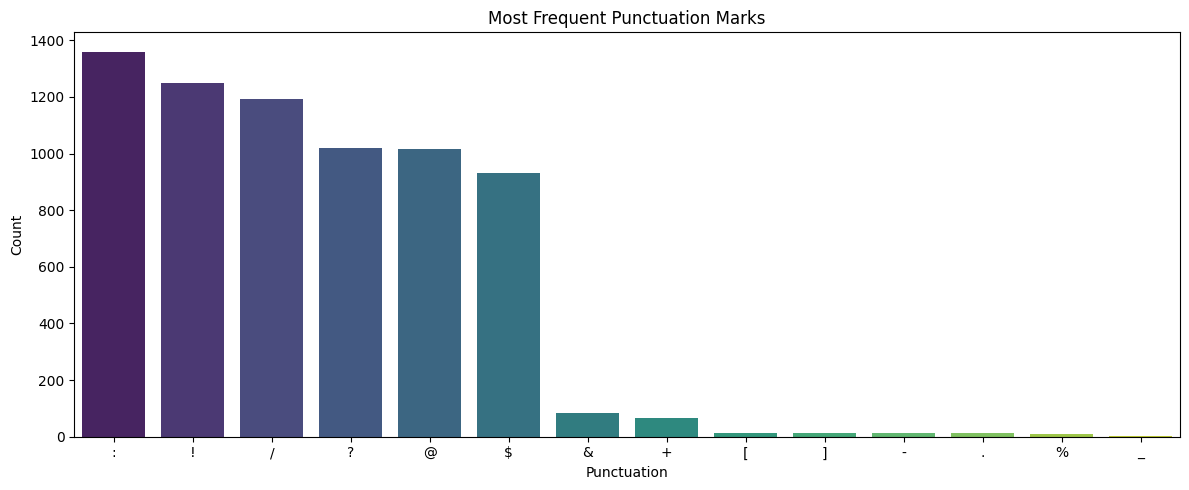

C:\Users\MSI\AppData\Local\Temp\ipykernel_29984\1858862066.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stopword_summary, x="text_type", y="stopword_count", palette="Set2")


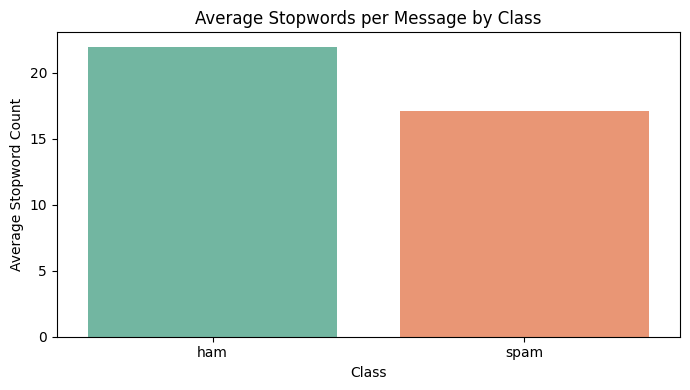

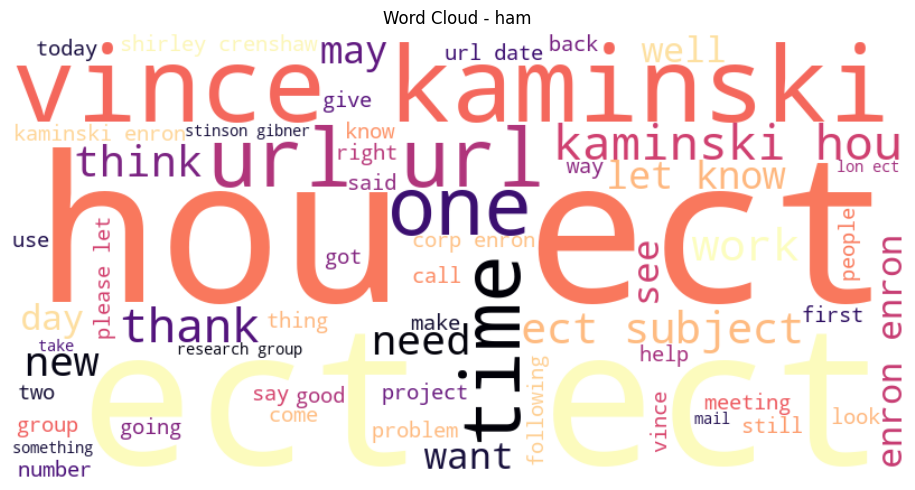

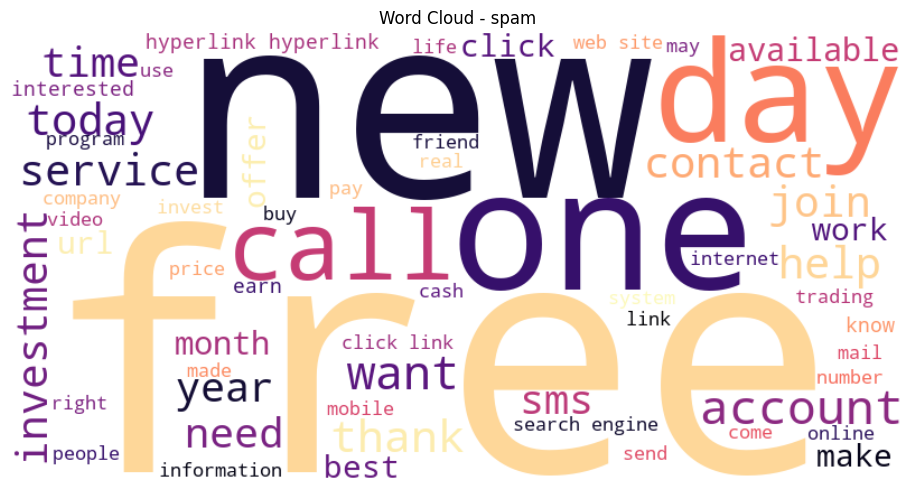


===== HAM SAMPLE MESSAGES =====

Sample 1:
url url date 1635465 1635465 1635465t1635465 1635465 1635465 1635465 1635465 an article titled mac poses as much of challenge to linux as to windows is both insightful and missing the point the general thrust of the article is dead on it s just the sort of stuff i ve been saying to folks

Sample 2:
edith terry scott i spoke briefly with edith terry from our dc office there is not a good fit for my group but she could be a great asset for you i have her resume in case you are hiring and would like to take a look at her vince

Sample 3:
i liked the new mobile

===== SPAM SAMPLE MESSAGES =====

Sample 1:
join focus groups to earn money a la carte research recruits for focus groups across the country focus groups are an easy way to make some extra money for just a couple of hours of your time each group is only for the purpose of learning your opinions you can be assured that there will be no sales presentation and you will not be asked to buy an

C:\Users\MSI\AppData\Local\Temp\ipykernel_29984\1858862066.py:123: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_messages = df.groupby("text_type").apply(lambda x: x.sample(3, random_state=42)).reset_index(drop=True)


In [14]:
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

# ---------------------------
# Setup
# ---------------------------
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

df["text"] = df["text"].astype(str)

# ---------------------------
# 1) Class imbalance check
# ---------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="text_type", order=df["text_type"].value_counts().index, palette="Set2")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["text_type"].value_counts())
print(f"\nImbalance ratio: {df['text_type'].value_counts().max() / df['text_type'].value_counts().min():.2f}")

# ---------------------------
# 2) Average message length by class
# ---------------------------
df["char_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

avg_len = df.groupby("text_type")[["char_len", "word_count"]].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(data=avg_len, x="text_type", y="word_count", palette="Set2")
plt.title("Average Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Average Words")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=avg_len, x="text_type", y="char_len", palette="Set2")
plt.title("Average Character Count by Class")
plt.xlabel("Class")
plt.ylabel("Average Characters")
plt.tight_layout()
plt.show()

# ---------------------------
# 3) Punctuation frequency
# ---------------------------
punct_counter = Counter()

for text in df["text"]:
    for ch in text:
        if ch in string.punctuation:
            punct_counter[ch] += 1

punct_df = pd.DataFrame(punct_counter.items(), columns=["punctuation", "count"]).sort_values("count", ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=punct_df.head(15), x="punctuation", y="count", palette="viridis")
plt.title("Most Frequent Punctuation Marks")
plt.xlabel("Punctuation")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ---------------------------
# 4) Stopword usage
# ---------------------------
def count_stopwords(text):
    tokens = re.findall(r"\b\w+\b", text.lower())
    return sum(1 for t in tokens if t in stop_words)

df["stopword_count"] = df["text"].apply(count_stopwords)

stopword_summary = df.groupby("text_type")["stopword_count"].mean().reset_index()

plt.figure(figsize=(7, 4))
sns.barplot(data=stopword_summary, x="text_type", y="stopword_count", palette="Set2")
plt.title("Average Stopwords per Message by Class")
plt.xlabel("Class")
plt.ylabel("Average Stopword Count")
plt.tight_layout()
plt.show()

# ---------------------------
# 5) Word clouds by class
# ---------------------------
for label, group in df.groupby("text_type"):
    text_blob = " ".join(group["text"].astype(str))
    cleaned = re.sub(r"[^a-zA-Z\s]", " ", text_blob.lower())
    tokens = [t for t in cleaned.split() if t not in stop_words and len(t) > 2]
    word_text = " ".join(tokens)

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=60,
        colormap="magma"
    ).generate(word_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"Word Cloud - {label}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# ---------------------------
# 6) Sample messages from each class
# ---------------------------
sample_messages = df.groupby("text_type").apply(lambda x: x.sample(3, random_state=42)).reset_index(drop=True)

for label, group in sample_messages.groupby("text_type"):
    print(f"\n===== {label.upper()} SAMPLE MESSAGES =====")
    for i, msg in enumerate(group["text"].tolist(), start=1):
        print(f"\nSample {i}:")
        print(msg[:500])